
#THE PERCEPTRON ALGORITHM

----------------------------------



=====================

What it does?
------------
The perceptron is the simplest linear binary classifier. Given labeled points
(x_i, y_i) with y_i in {-1, +1}, it tries to find a hyperplane (defined by a
weight vector w and bias b) that separates the two classes:

    predict(x) = sign(w . x + b)

How it learns?
------------------------------

Initialize the parameters by setting **w = 0** and **b = 0**. Then, repeat the training process for several epochs. During each epoch, iterate through every training example $(x_i, y_i)$. For each example, check whether it is misclassified by evaluating the condition $y_i \cdot (w \cdot x_i + b) \leq 0$. If the condition is true, update the model parameters using the Perceptron learning rule:

$$
w = w + \text{learning_rate} \cdot y_i \cdot x_i
$$

$$
b = b + \text{learning_rate} \cdot y_i
$$

Continue repeating this process until there are no more misclassified training examples or until the maximum number of epochs is reached.

Why it works?
-----------------------------
The quantity  y_i * (w . x_i + b)  is positive when the point is
  correctly classified, and negative/zero when it is wrong.
  This is exactly the "margin" of the prediction.

 When a point is misclassified, updating
        w <- w + lr * y_i * x_i
  increases the margin for THAT point:

      
\begin{aligned}
y_i \left( (w + \mathrm{lr}\, y_i x_i) \cdot x_i + b \right)
&= y_i (w \cdot x_i + b) + \mathrm{lr}\, y_i^2 \|x_i\|^2 \\
&= y_i (w \cdot x_i + b) + \mathrm{lr}\, \|x_i\|^2
\qquad \text{(since } y_i^2 = 1\text{)}
\end{aligned}




  The margin grows by lr * ||x_i||^2 >= 0, i.e. every update nudges the
  hyperplane's decision boundary TOWARD correctly classifying that point.
  Geometrically: w is rotated toward x_i (if y_i = +1) or away from x_i
  (if y_i = -1), moving the boundary in the right direction.

- Perceptron convergence theorem: if the data is linearly separable (some
  hyperplane with margin gamma > 0 exists), then the perceptron makes at
  most  (R/gamma)^2  mistakes total, where R = max ||x_i||.
  So training is *guaranteed* to converge to a separating hyperplane in a
  finite number of updates -- it doesn't loop forever.

- If the data is NOT linearly separable, the algorithm will never fully
  converge (it will keep correcting mistakes forever), which is why in
  practice we cap the number of epochs.


Converged after 2 epoch(s). Data is linearly separable.
Final weights: [2.24377366 1.16801272]
Final bias: 1.0
Training accuracy: 100.0%
Saved plot to perceptron_result.png


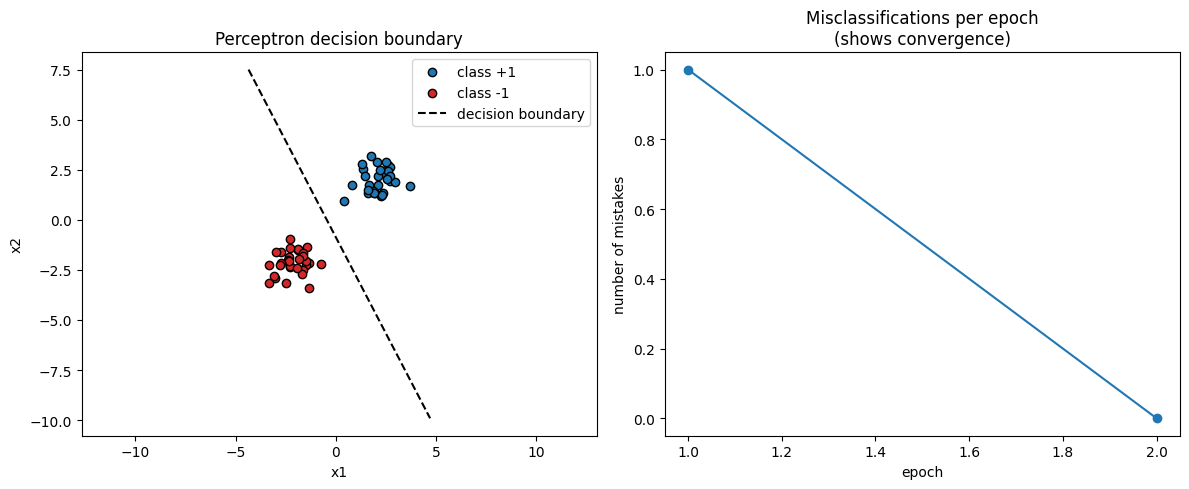

In [3]:
import numpy as np
import matplotlib.pyplot as plt


class Perceptron:
    def __init__(self, learning_rate: float = 1.0, n_epochs: int = 100):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.w = None      # weight vector
        self.b = 0.0        # bias
        self.errors_per_epoch = []  # for tracking convergence

    def net_input(self, X):
        """Compute w . x + b for every row of X."""
        return X @ self.w + self.b

    def predict(self, X):
        """Return -1 / +1 class predictions."""
        return np.where(self.net_input(X) >= 0, 1, -1)

    def fit(self, X, y):
        """
        Train using the classic perceptron update rule.
        X: (n_samples, n_features)
        y: (n_samples,) with values in {-1, +1}
        """
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0

        for epoch in range(self.n_epochs):
            errors = 0
            for x_i, y_i in zip(X, y):
                # Condition for misclassification: y_i*(w.x_i + b) <= 0
                margin = y_i * (np.dot(self.w, x_i) + self.b)
                if margin <= 0:
                    self.w += self.lr * y_i * x_i
                    self.b += self.lr * y_i
                    errors += 1
            self.errors_per_epoch.append(errors)

            if errors == 0:
                print(f"Converged after {epoch + 1} epoch(s). "
                      f"Data is linearly separable.")
                break
        else:
            print(f"Stopped after {self.n_epochs} epochs "
                  f"(may not be linearly separable).")

        return self


def make_demo_data(n_per_class: int = 30, seed: int = 42):
    """Create two linearly separable 2D Gaussian blobs, labeled -1/+1."""
    rng = np.random.default_rng(seed)
    class_pos = rng.normal(loc=[2, 2], scale=0.8, size=(n_per_class, 2))
    class_neg = rng.normal(loc=[-2, -2], scale=0.8, size=(n_per_class, 2))
    X = np.vstack([class_pos, class_neg])
    y = np.hstack([np.ones(n_per_class), -np.ones(n_per_class)])
    return X, y


def plot_result(X, y, model: Perceptron):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- left: data + decision boundary ---
    ax = axes[0]
    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="tab:blue",
               label="class +1", edgecolor="k")
    ax.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color="tab:red",
               label="class -1", edgecolor="k")

    # decision boundary: w0*x1 + w1*x2 + b = 0  ->  x2 = -(w0*x1 + b)/w1
    x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    if model.w[1] != 0:
        y_vals = -(model.w[0] * x_vals + model.b) / model.w[1]
        ax.plot(x_vals, y_vals, "k--", label="decision boundary")

    ax.set_title("Perceptron decision boundary")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    ax.axis("equal")

    # --- right: errors per epoch (shows convergence) ---
    ax2 = axes[1]
    ax2.plot(range(1, len(model.errors_per_epoch) + 1),
              model.errors_per_epoch, marker="o")
    ax2.set_title("Misclassifications per epoch\n(shows convergence)")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("number of mistakes")

    plt.tight_layout()
    plt.savefig("perceptron_result.png", dpi=150)
    print("Saved plot to perceptron_result.png")


if __name__ == "__main__":
    X, y = make_demo_data()

    model = Perceptron(learning_rate=1.0, n_epochs=50)
    model.fit(X, y)

    print("Final weights:", model.w)
    print("Final bias:", model.b)

    preds = model.predict(X)
    accuracy = np.mean(preds == y)
    print(f"Training accuracy: {accuracy * 100:.1f}%")

    plot_result(X, y, model)